<center><p float="center">
  <img src="https://upload.wikimedia.org/wikipedia/commons/e/e9/4_RGB_McCombs_School_Brand_Branded.png" width="300" height="100"/>
  <img src="https://mma.prnewswire.com/media/1458111/Great_Learning_Logo.jpg?p=facebook" width="200" height="100"/>
</p></center>

<center><font size=10>Data Science with Generative AI: Applications to Business</font></center>
<center><font size=6>Robust Data Modeling with Ensembling and Tuning Techniques</font></center>

<center><img src="https://images.pexels.com/photos/7235894/pexels-photo-7235894.jpeg?auto=compress&cs=tinysrgb&w=1260&h=750&dpr=2" width="800" height="500"></center>

<center><font size=6>Visa Approval Facilitation</font></center>

# **Problem Statement**

## Context

Business communities in the United States are facing high demand for human resources, but one of the constant challenges is identifying and attracting the right talent, which is perhaps the most important element in remaining competitive. Companies in the United States look for hard-working, talented, and qualified individuals both locally as well as abroad.

The Immigration and Nationality Act (INA) of the US permits foreign workers to come to the United States to work on either a temporary or permanent basis. The act also protects US workers against adverse impacts on their wages or working conditions by ensuring US employers' compliance with statutory requirements when they hire foreign workers to fill workforce shortages. The immigration programs are administered by the Office of Foreign Labor Certification (OFLC).

OFLC processes job certification applications for employers seeking to bring foreign workers into the United States and grants certifications in those cases where employers can demonstrate that there are not sufficient US workers available to perform the work at wages that meet or exceed the wage paid for the occupation in the area of intended employment.

## Objective

In FY 2016, the OFLC processed 775,979 employer applications for 1,699,957 positions for temporary and permanent labor certifications. This was a nine percent increase in the overall number of processed applications from the previous year. The process of reviewing every case is becoming a tedious task as the number of applicants is increasing every year.

The increasing number of applicants every year calls for a Machine Learning based solution that can help in shortlisting the candidates having higher chances of VISA approval. OFLC has hired the firm EasyVisa for data-driven solutions. You as a data  scientist at EasyVisa have to analyze the data provided and, with the help of a classification model:

* Facilitate the process of visa approvals.
* Recommend a suitable profile for the applicants for whom the visa should be certified or denied based on the drivers that significantly influence the case status.

## Data Description

The data contains the different attributes of employee and the employer. The detailed data dictionary is given below.

* case_id: ID of each visa application
* continent: Information of continent the employee
* education_of_employee: Information of education of the employee
* has_job_experience: Does the employee has any job experience? Y= Yes; N = No
* requires_job_training: Does the employee require any job training? Y = Yes; N = No
* no_of_employees: Number of employees in the employer's company
* yr_of_estab: Year in which the employer's company was established
* region_of_employment: Information of foreign worker's intended region of employment in the US.
* prevailing_wage:  Average wage paid to similarly employed workers in a specific occupation in the area of intended employment. The purpose of the prevailing wage is to ensure that the foreign worker is not underpaid compared to other workers offering the same or similar service in the same area of employment.
* unit_of_wage: Unit of prevailing wage. Values include Hourly, Weekly, Monthly, and Yearly.
* full_time_position: Is the position of work full-time? Y = Full Time Position; N = Part Time Position
* case_status:  Flag indicating if the Visa was certified or denied

## Note: This is a sample solution for the project. Projects will NOT be graded on the basis of how well the submission matches this sample solution. Projects will be graded on the basis of the rubric only.

# **Importing necessary libraries**

In [ ]:
!pip install -q numpy pandas scikit-learn matplotlib seaborn xgboost

**Note**: *After running the above cell, kindly restart the notebook kernel and run all cells sequentially from the start again.*

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

from sklearn.ensemble import (
    BaggingClassifier,
    RandomForestClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier,
    StackingClassifier
)

from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn import metrics
from sklearn.model_selection import GridSearchCV, train_test_split

# **Loading the dataset**

In [ ]:
from google.colab import drive
import pandas as pd
drive.mount('/content/drive')
# full data set
full_data_original = pd.read_csv('/content/drive/MyDrive/UT Austin/EasyVisa.csv')

# make a copy of original dataset
full_data=full_data_original.copy()


Mounted at /content/drive


In the following, I used 20% data to run through EDA and models first. Before I start writing analyses, I will use full data to run through everything so I can get the full picture.

In [60]:

data = full_data.copy()
print("Final dataset shape:", data.shape)

Final dataset shape: (25447, 10)


# **Overview of the Dataset**

* Observations

* Sanity checks

In [ ]:
# let's view the first 5 rows of the data
full_data.head()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


In [ ]:
# let's view the last 5 rows of the data
full_data.tail()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
25475,EZYV25476,Asia,Bachelor's,Y,Y,2601,2008,South,77092.57,Year,Y,Certified
25476,EZYV25477,Asia,High School,Y,N,3274,2006,Northeast,279174.79,Year,Y,Certified
25477,EZYV25478,Asia,Master's,Y,N,1121,1910,South,146298.85,Year,N,Certified
25478,EZYV25479,Asia,Master's,Y,Y,1918,1887,West,86154.77,Year,Y,Certified
25479,EZYV25480,Asia,Bachelor's,Y,N,3195,1960,Midwest,70876.91,Year,Y,Certified


In [ ]:
# let's check the data types of the columns in the dataset
full_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   case_id                25480 non-null  object 
 1   continent              25480 non-null  object 
 2   education_of_employee  25480 non-null  object 
 3   has_job_experience     25480 non-null  object 
 4   requires_job_training  25480 non-null  object 
 5   no_of_employees        25480 non-null  int64  
 6   yr_of_estab            25480 non-null  int64  
 7   region_of_employment   25480 non-null  object 
 8   prevailing_wage        25480 non-null  float64
 9   unit_of_wage           25480 non-null  object 
 10  full_time_position     25480 non-null  object 
 11  case_status            25480 non-null  object 
dtypes: float64(1), int64(2), object(9)
memory usage: 2.3+ MB




*   There are a total of 12 columns and 5096 observations in the dataset.
*   No missing value is present.
*   Most categorical variables are stored as object type, while no_of_employees, yr_of_estab, and prevailing_wage are numerical variables.



In [ ]:
# let's check for duplicate values in the data
full_data.duplicated().sum()

np.int64(0)



*  No duplicate value is present.

In [ ]:
# Checking for the null value in the dataset
full_data.isna().sum()

,0
case_id,0
continent,0
education_of_employee,0
has_job_experience,0
requires_job_training,0
no_of_employees,0
yr_of_estab,0
region_of_employment,0
prevailing_wage,0
unit_of_wage,0




*   No NaN value is present.


##Let's check the number of unique values in each column

In [ ]:
full_data.nunique()

,0
case_id,25480
continent,6
education_of_employee,4
has_job_experience,2
requires_job_training,2
no_of_employees,7105
yr_of_estab,199
region_of_employment,5
prevailing_wage,25454
unit_of_wage,4


The case_id column contains a unique identifier for each visa application. Since it does not provide predictive information about visa approval or denial, it will be removed before model building.

In [ ]:
# let's view the statistical summary of the numerical columns in the data
full_data.describe().T

,count,mean,std,min,25%,50%,75%,max
no_of_employees,25480.0,5667.043210,22877.928848,-26.0000,1022.00,2109.00,3504.0000,602069.00
yr_of_estab,25480.0,1979.409929,42.366929,1800.0000,1976.00,1997.00,2005.0000,2016.00
prevailing_wage,25480.0,74455.814592,52815.942327,2.1367,34015.48,70308.21,107735.5125,319210.27




*   **no_of_employees:** The number of employees appears to be highly
right-skewed, as the mean (5,667) is substantially larger than the median (2,109). The presence of extremely large values and a negative minimum value suggests potential outliers and possible data quality issues that should be investigated further.
*   **yr_of_estab:** Most companies in the dataset were established between 1976 and 2005, with a median establishment year of 1997. The variable does not appear to contain extreme outliers and represents organizations with a wide range of operating histories.
*   **prevailing_wage:** The prevailing wage ranges from approximately $2 to $319,210, with a median wage of about $70,308. Since the mean wage is slightly higher than the median, the distribution appears moderately right-skewed, suggesting the presence of some high-wage applications.





In [ ]:
# Investigate the no_of_employees column
(full_data["no_of_employees"] < 0).sum()

np.int64(33)

The **no_of_employees** variable contains 33 negative values. Since a company cannot have a negative number of employees, these observations are likely data entry errors. As they represent only 0.13% of the dataset, they will be removed during data preprocessing.

##Checking the value count for each category of categorical variables

In [ ]:
for col in full_data.columns:
    if full_data[col].dtype == 'object':
        print(f"Value counts for column: {col}")
        print(full_data[col].value_counts())
        print("\n" + "-"*50 + "\n")

Value counts for column: case_id
case_id
EZYV25480    1
EZYV01       1
EZYV02       1
EZYV03       1
EZYV04       1
            ..
EZYV13       1
EZYV12       1
EZYV11       1
EZYV10       1
EZYV09       1
Name: count, Length: 25480, dtype: int64

--------------------------------------------------

Value counts for column: continent
continent
Asia             16861
Europe            3732
North America     3292
South America      852
Africa             551
Oceania            192
Name: count, dtype: int64

--------------------------------------------------

Value counts for column: education_of_employee
education_of_employee
Bachelor's     10234
Master's        9634
High School     3420
Doctorate       2192
Name: count, dtype: int64

--------------------------------------------------

Value counts for column: has_job_experience
has_job_experience
Y    14802
N    10678
Name: count, dtype: int64

--------------------------------------------------

Value counts for column: requires_job_trai

**continent**

* Most visa applications come from Asia (16,861), accounting for the majority of applicants.
* Applications from Oceania (192) and Africa (551) are relatively rare.

**education_of_employee**

* Most applicants hold either a Bachelor’s degree (10,234) or Master’s degree (9,634).
* Applicants with a Doctorate (2,192) represent the smallest education group.

**has_job_experience**

* A slight majority of applicants have prior job experience (14,802 vs. 10,678).
* The dataset contains a reasonably balanced distribution of experienced and inexperienced applicants.

**requires_job_training**

* Most positions do not require job training (22,525).
* Only a small proportion of applications involve jobs requiring additional training (2,955).

**region_of_employment**

* The Northeast (7,195) and South (7,017) account for the largest share of employment locations.
* The Island region (375) has very few applications compared to other regions.

**unit_of_wage**

* The overwhelming majority of wages are reported on a yearly basis (22,962).
* Monthly and weekly wage units are relatively uncommon.

**full_time_position**

* Most visa applications are for full-time positions (22,773).
* Only a small fraction of applications are for non-full-time positions (2,707).

**case_status (Target Variable)**

* The dataset is moderately imbalanced, with more Certified (17,018) cases than Denied (8,462) cases.
* Approximately 67% of applications are certified, while 33% are denied.

# <a name='link2'>**Exploratory Data Analysis (EDA)**</a>

- EDA is an important part of any project involving data.
- It is important to investigate and understand the data better before building a model with it.
- A few questions have been mentioned below which will help you approach the analysis in the right manner and generate insights from the data.
- A thorough analysis of the data, in addition to the questions mentioned below, should be done.

**Leading Questions**

What is the distribution of visa case statuses (certified vs. denied)?


1. What is the distribution of visa case statuses (certified vs. denied)?
2. How does the education level of employees impact visa approval rates?
3. Is there a significant difference in visa approval rates between employees with and without prior job experience?
4. How does the prevailing wage affect visa approval? Do higher wages lead to higher chances of approval?
5. Do certain regions in the US have higher visa approval rates compared to others?
6. How does the number of employees in a company influence visa approval? Do larger companies have a higher approval rate?
7. Are visa approval rates different across various continents of employees? Which continent has the highest and lowest approval rates?

###Univariate analysis

In [ ]:
# function to plot a boxplot and a histogram along the same scale.


def histogram_boxplot(data, feature, figsize=(12, 7), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (12,7))
    kde: whether to the show density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a star will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins, palette="winter"
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

In [ ]:
# function to create labeled barplots


def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 1, 5))
    else:
        plt.figure(figsize=(n + 1, 5))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n].sort_values(),
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

Observations on Continent

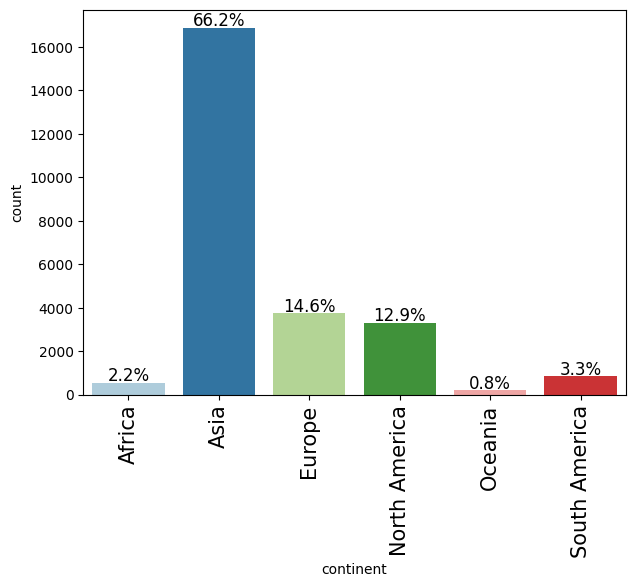

In [ ]:
# observations on continent
labeled_barplot(data, "continent", perc=True)

A significant majority of visa applications originate from Asia, making it the dominant continent for applicants in this sample.
Europe and North America represent the next largest groups, though their numbers are considerably lower than Asia's.

Observations on education of employees

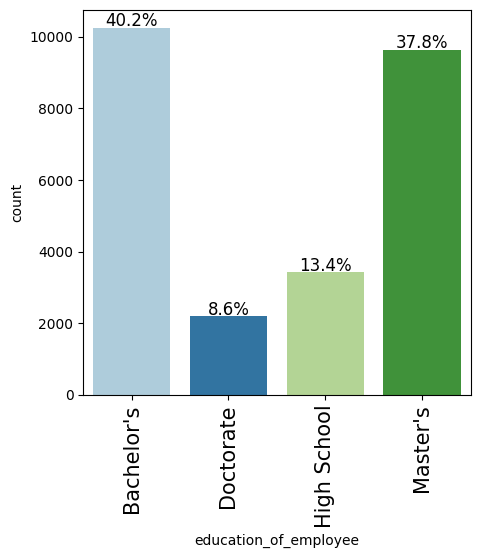

In [ ]:
# observations on education of employees
labeled_barplot(data, "education_of_employee",perc=True)

The most common education levels among applicants are Bachelor's degrees and Master's degrees , indicating that a highly educated workforce is applying for visas.

Doctorate holders represent the smallest proportion of applicants in this dataset.

Observations on has_job_experience

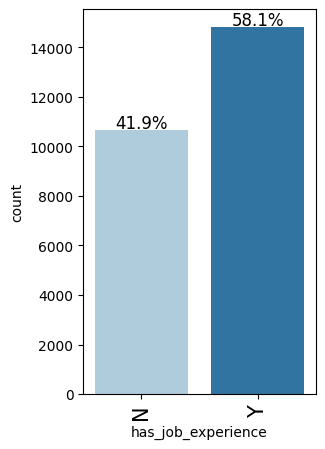

In [ ]:

labeled_barplot(data, "has_job_experience",perc=True)

58% people have job experience while 42% don't.

Observations on requires_job_training

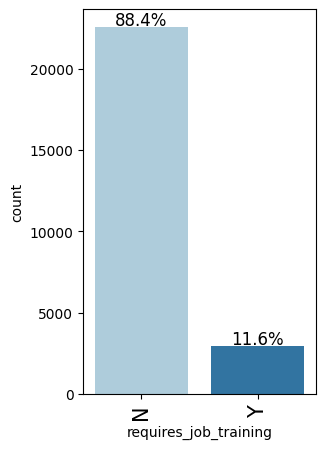

In [ ]:
labeled_barplot(data, "requires_job_training",perc=True)

Most of people (88.4%) don't require job training.

Observations on no_of_employees

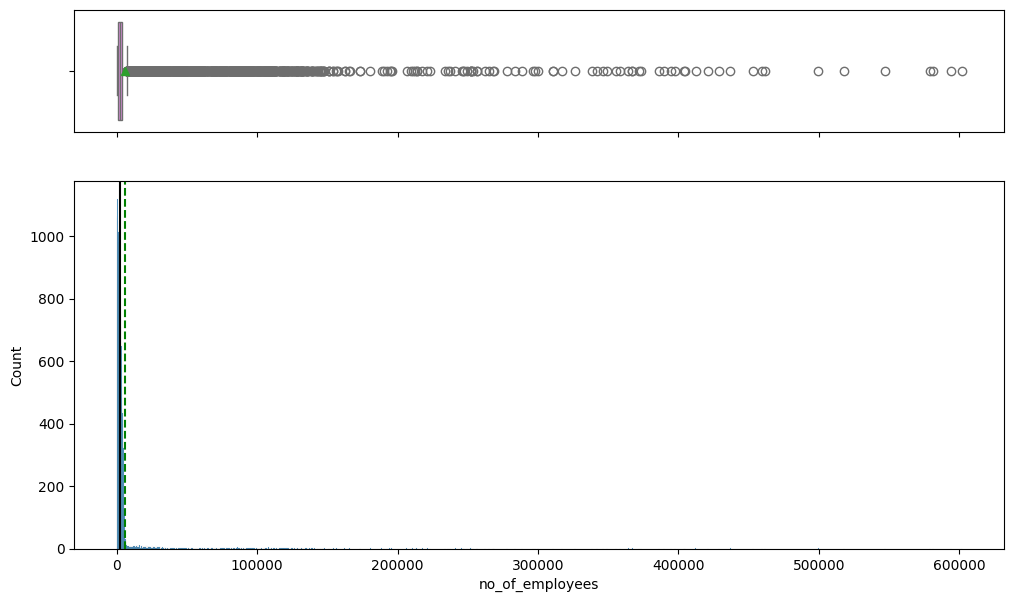

In [ ]:
histogram_boxplot(data, "no_of_employees")

As it was shown in the statistical summary, the histogram and the boxplot clearly show that the data is heavily concentrated towards lower values, with a very long tail extending to the right. This indicates that most companies have a relatively small number of employees and a indicator of right-skewness.

Observations on yr_of_estab

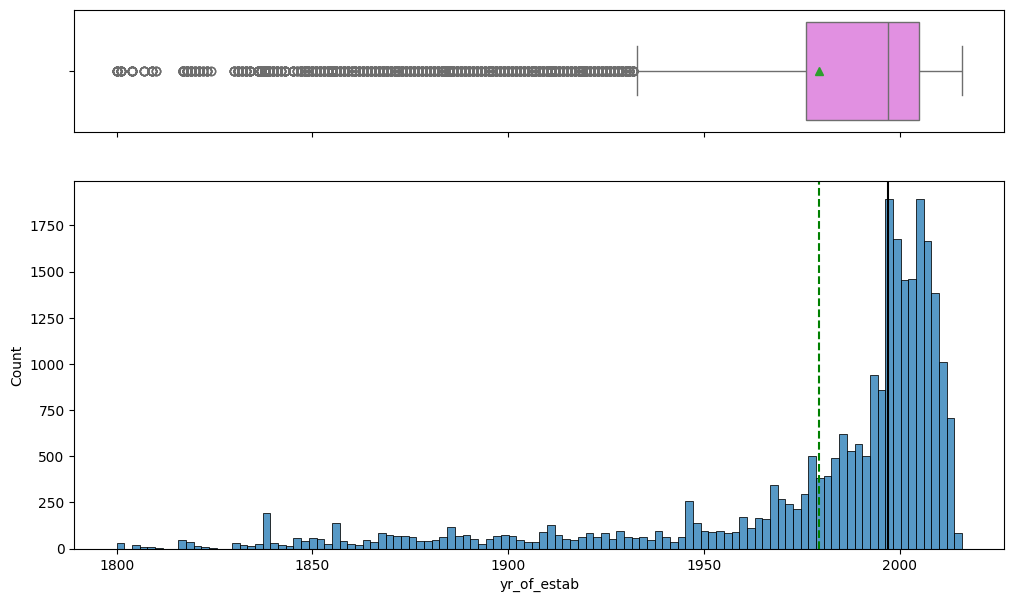

In [ ]:
histogram_boxplot(data, "yr_of_estab")

The histogram shows a distribution that is moderately left-skewed, meaning there's a longer tail towards older establishment years (smaller values) and a concentration of companies established more recently. The peak of the distribution is around the early 2000s.

Observations on region_of_employment

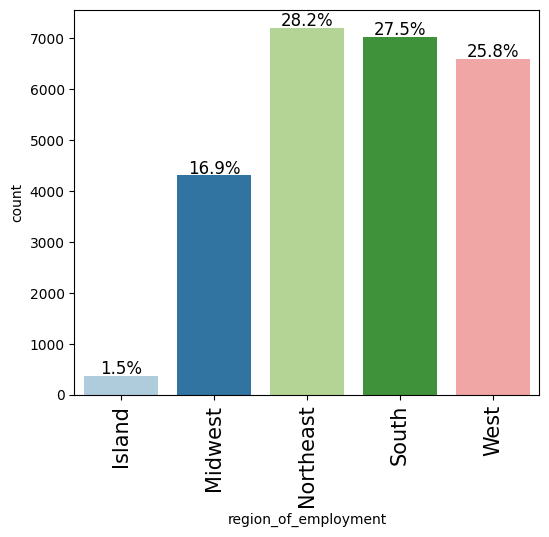

In [ ]:
labeled_barplot(data, "region_of_employment",perc=True)

The three most frequent regions of employment are: Northeast, South, and West. They are evenly distributed.

Observations on prevailing_wage

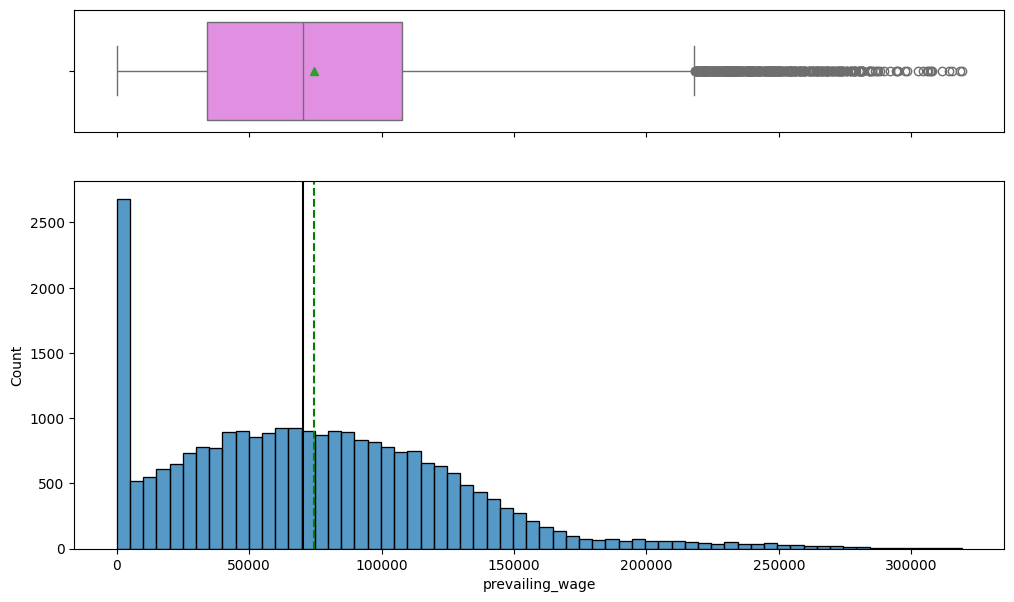

In [ ]:
histogram_boxplot(data, "prevailing_wage")

Both the histogram and the boxplot clearly indicate a right-skewed distribution. This means that a large majority of prevailing wages are concentrated at the lower end of the scale, with a few exceptionally high wages pulling the distribution to the right.

The mean (dashed green line in the histogram, green triangle in the boxplot) is higher than the median (solid black line in the histogram, line inside the boxplot). This is a strong indicator of the right-skewness and the influence of higher wage values on the average.

Observations on unit_of_wage

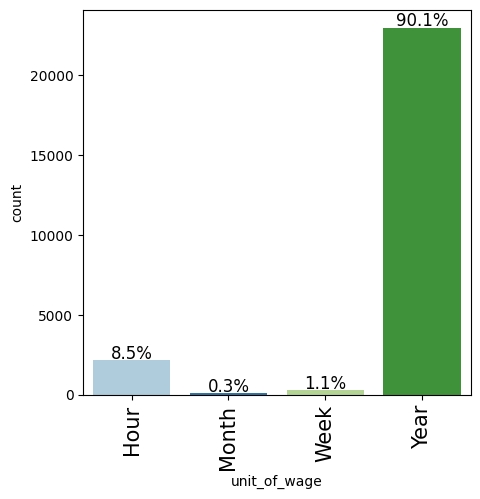

In [ ]:
labeled_barplot(data, "unit_of_wage",perc=True)

Most applications use **Year** as the unit of wage. So we can say that the column of **prevailing_wage** can mostly be interpreted as annual wage.

Observations on full_time_position

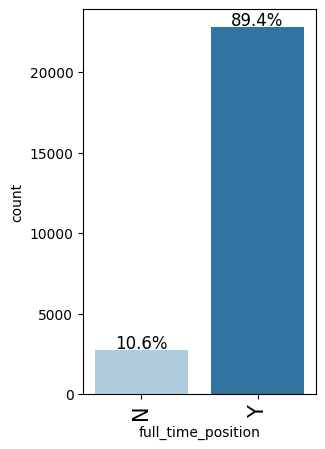

In [ ]:
labeled_barplot(data, "full_time_position",perc=True)

Most of people have full-time positions.

Observations on case_status

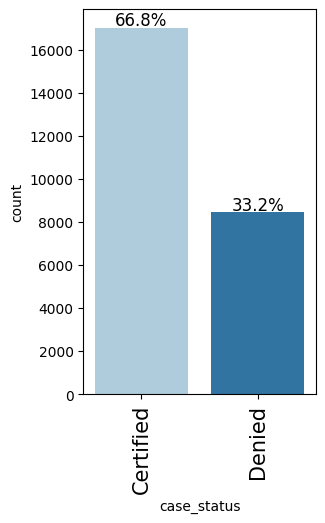

In [ ]:
labeled_barplot(data, "case_status", perc=True)

Most people were certified in the cases (66.8%) and one-third of applicants were denied (33.2%).

###Leading Questions

1. What is the distribution of visa case statuses (certified vs. denied)?



Ans: As you can see, 66.7% of applications are certified while 33.3% of applications are denied.

###Bivariate Analysis

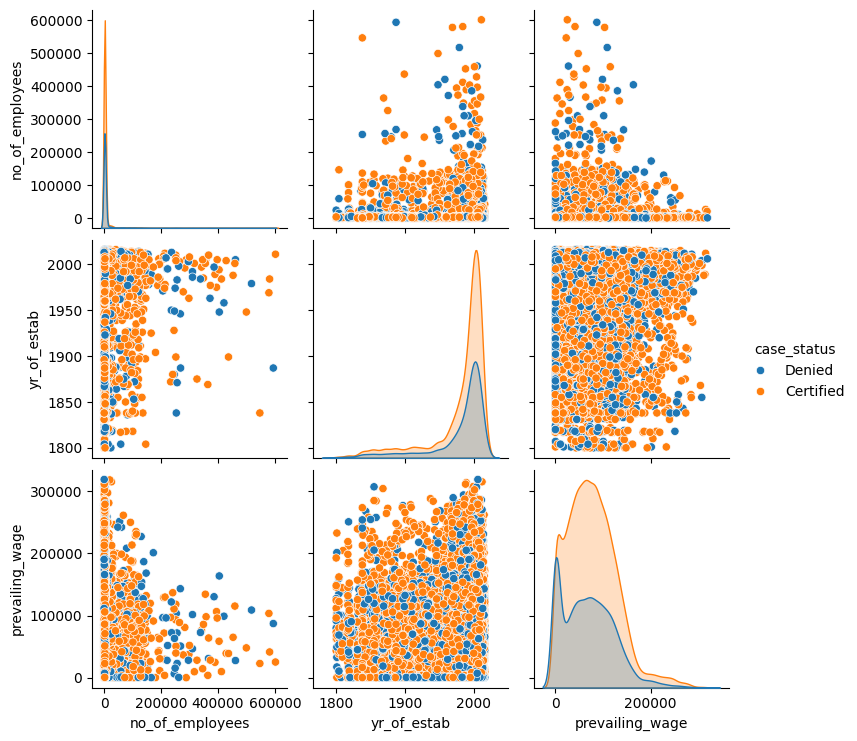

In [ ]:
sns.pairplot(data, hue="case_status")

Overall, the scatter plots between pairs of numerical variables (`no_of_employees`, `yr_of_estab`, `prevailing_wage`) do not show strong linear or non-linear relationships that clearly separate 'Certified' from 'Denied' cases. The points for both statuses are largely intermingled, suggesting that these numerical features alone might not be strong discriminators for `case_status` in a simple bivariate context.

In [ ]:
# function to plot stacked bar chart


def stacked_barplot(data, predictor, target):
    """
    Print the category counts and plot a stacked bar chart

    data: dataframe
    predictor: independent variable
    target: target variable
    """
    count = data[predictor].nunique()
    sorter = data[target].value_counts().index[-1]
    tab1 = pd.crosstab(data[predictor], data[target], margins=True).sort_values(
        by=sorter, ascending=False
    )
    print(tab1)
    print("-" * 120)
    tab = pd.crosstab(data[predictor], data[target], normalize="index").sort_values(
        by=sorter, ascending=False
    )
    tab.plot(kind="bar", stacked=True, figsize=(count + 1, 5))
    plt.legend(
        loc="lower left",
        frameon=False,
    )
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
    plt.show()

**Leading Question:**

7. Are visa approval rates different across various continents of employees? Which continent has the highest and lowest approval rates?

Continent vs Case_status

case_status    Certified  Denied    All
continent                              
All                17018    8462  25480
Asia               11012    5849  16861
North America       2037    1255   3292
Europe              2957     775   3732
South America        493     359    852
Africa               397     154    551
Oceania              122      70    192
------------------------------------------------------------------------------------------------------------------------


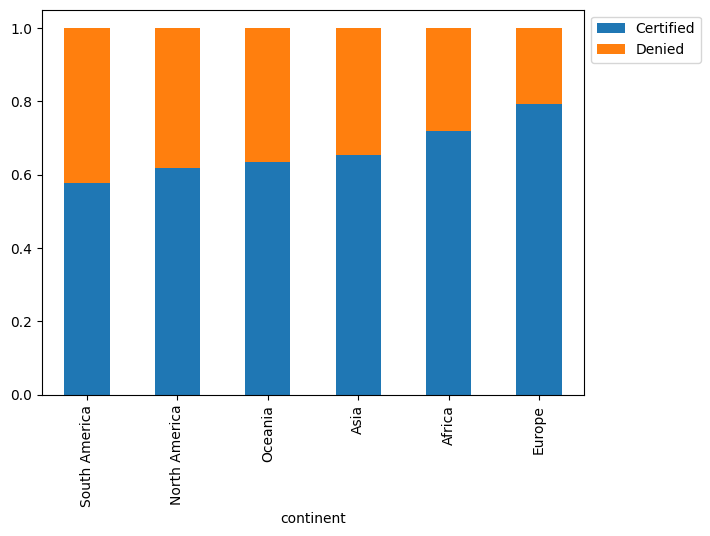

In [ ]:
stacked_barplot(data, "continent", "case_status")

Ans:
*   **Europe** has the highest proportion of approval cases, with approximately 78.7% of applications being certified and 21.3% denied.
*   **South America** appears to have the lowest approval rate, with only about 58% of applications certified and 42% denied.
*   **Asia** contributes the largest number of applications and therefore has the greatest impact on overall outcomes.


Education of employee vs case_status

**Leading Question**

2. How does the education level of employees impact visa approval rates?

case_status            Certified  Denied    All
education_of_employee                          
All                        17018    8462  25480
Bachelor's                  6367    3867  10234
High School                 1164    2256   3420
Master's                    7575    2059   9634
Doctorate                   1912     280   2192
------------------------------------------------------------------------------------------------------------------------


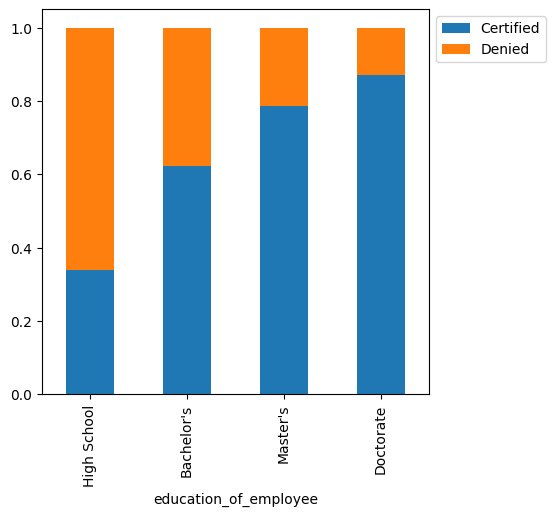

In [ ]:
stacked_barplot(data, "education_of_employee", "case_status")

Ans: Education appears to be one of the strongest factors associated with visa certification. Applicants holding Master's and Doctorare degrees exhibit substantially higher certification rates than those with Bachelor's or High School Education, suggesting that highly skilled workers are more likely to satisfy visa requirements.

has_job_experience vs case_status

**Leading Questions**


3. Is there a significant difference in visa approval rates between employees with and without prior job experience?

case_status         Certified  Denied    All
has_job_experience                          
All                     17018    8462  25480
N                        5994    4684  10678
Y                       11024    3778  14802
------------------------------------------------------------------------------------------------------------------------


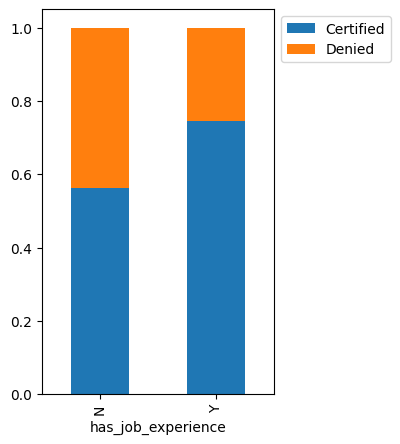

In [ ]:
stacked_barplot(data, "has_job_experience", "case_status")

Ans: Prior work experience is strongly associated with visa certification. Applicants with previous job experience achieve noticeably higher approval rates, indicating that employers may benefit from emphasizing relevant experience when preparing visa applications.

requires_job_training vs case_status

case_status            Certified  Denied    All
requires_job_training                          
All                        17018    8462  25480
N                          15012    7513  22525
Y                           2006     949   2955
------------------------------------------------------------------------------------------------------------------------


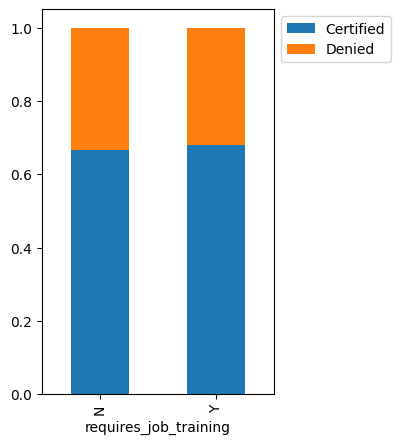

In [ ]:
stacked_barplot(data, "requires_job_training", "case_status")

There is no big difference in the case status between people who require and who don't require job training, but people who require job training seem to have slightly higher certification.

**Leading Question:**

6. How does the number of employees in a company influence visa approval? Do larger companies have a higher approval rate?

no_of_employees vs case_status

<Axes: xlabel='case_status', ylabel='no_of_employees'>

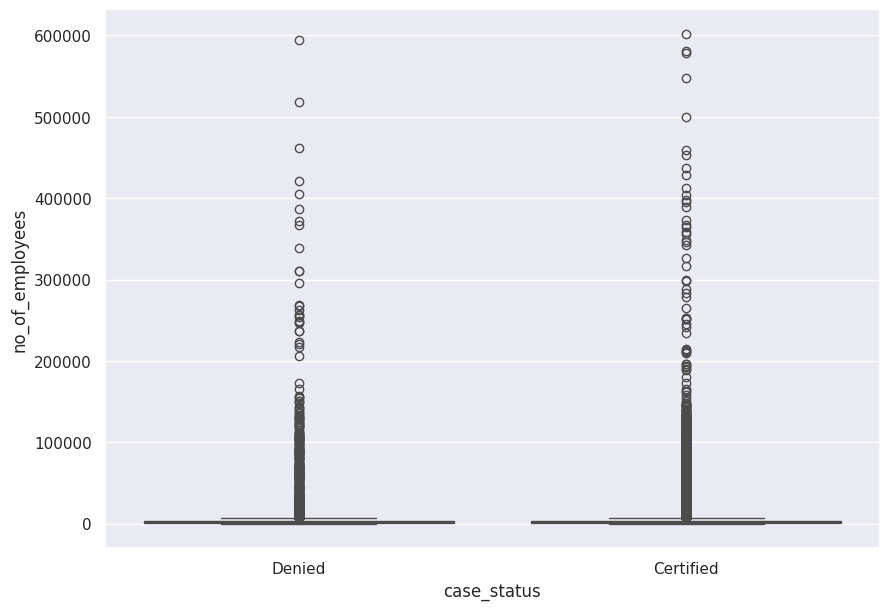

In [ ]:
sns.set(rc={"figure.figsize": (10, 7)})
sns.boxplot(x="case_status", y="no_of_employees", data=data, orient="vertical")

Ans:
Both 'Certified' and 'Denied' cases exhibit a very similar distribution for `no_of_employees`. The boxes for both categories are extremely compressed towards the lower end of the employee count, indicating that the vast majority of applications, regardless of their outcome, come from companies with a relatively small number of employees.

However, from the distribution of outliers (the companies that have more employees), we can see that the applicants from larger companies (the companies that have more employees) are more likely to have certified applications than the ones from smaller companies.

yr_of_estab vs case_status

<Axes: xlabel='case_status', ylabel='yr_of_estab'>

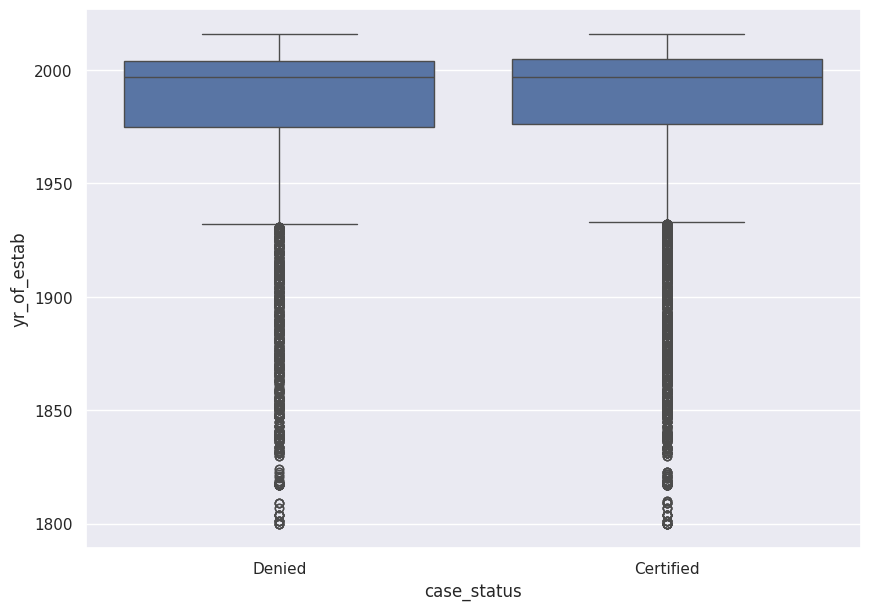

In [ ]:
sns.set(rc={"figure.figsize": (10, 7)})
sns.boxplot(x="case_status", y="yr_of_estab", data=data, orient="vertical")

 Both 'Certified' and 'Denied' cases show very similar distributions for the year of establishment. The median year of establishment (the line inside the box) and the interquartile ranges (the box itself) are nearly identical for both categories. Therefore, the `yr_of_estab` variable, when viewed in isolation, does not appear to be a strong individual predictor or differentiator for whether a visa application will be certified or denied.

region_of_employment vs case_status

case_status           Certified  Denied    All
region_of_employment                          
All                       17018    8462  25480
Northeast                  4526    2669   7195
West                       4100    2486   6586
South                      4913    2104   7017
Midwest                    3253    1054   4307
Island                      226     149    375
------------------------------------------------------------------------------------------------------------------------


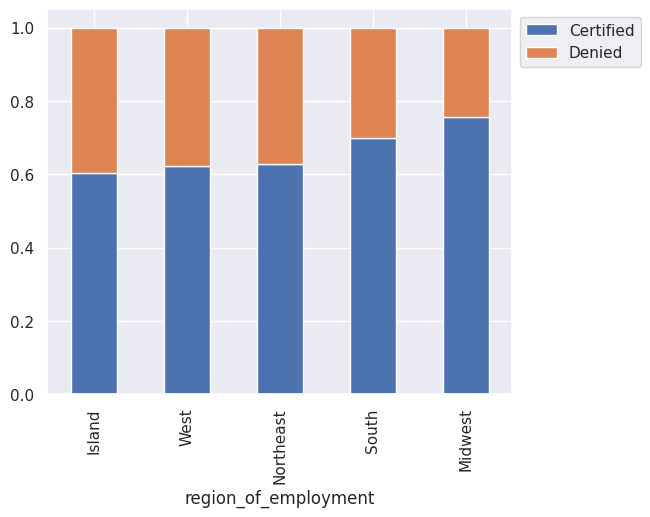

In [ ]:
stacked_barplot(data, "region_of_employment", "case_status")

**Leading Questions**


5. Do certain regions in the US have higher visa approval rates compared to others?

Ans: While the approval rates don't vary a lot among regions, we can see that the top three regions that have the highest visa approval rates are: Midwest, South, and Northeast.

Prevailing_wage vs case_status

<Axes: xlabel='case_status', ylabel='prevailing_wage'>

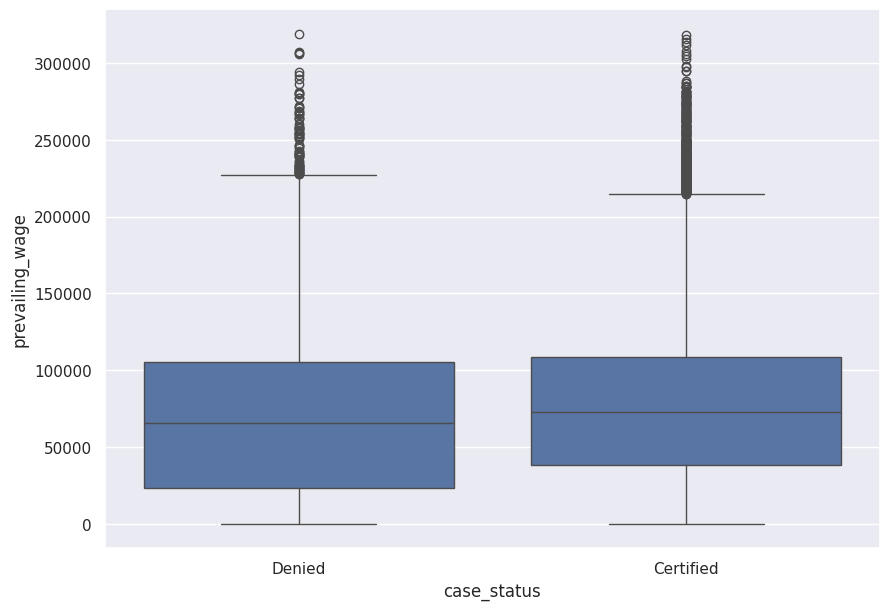

In [ ]:
sns.set(rc={"figure.figsize": (10, 7)})
sns.boxplot(x="case_status", y="prevailing_wage", data=data, orient="vertical")

**Leading Questions**

4. How does the prevailing wage affect visa approval? Do higher wages lead to higher chances of approval?

Ans: While the wage distributions overlap considerably, certified applications tend to exhibit a slighly higher median prevailing wage than denied applications. This suggests that wage level alone is not a decisive factor byt may contribute positively when combined with other qualifications.

Full_time_position vs case_status

case_status         Certified  Denied    All
full_time_position                          
All                     17018    8462  25480
Y                       15163    7610  22773
N                        1855     852   2707
------------------------------------------------------------------------------------------------------------------------


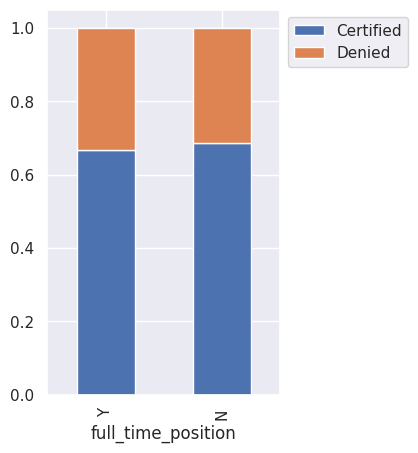

In [ ]:
stacked_barplot(data, "full_time_position", "case_status")

Whether the applicants have full-time positions or not doesn't affect approval rate.

Prevailing_wage and unit_of_wage (full_data set)

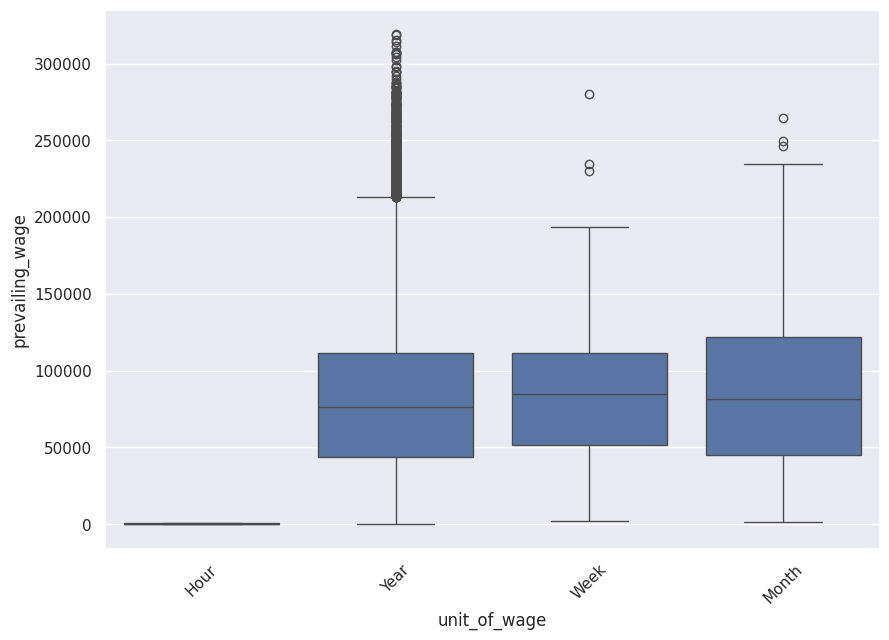

In [ ]:
sns.boxplot(x='unit_of_wage', y='prevailing_wage', data=full_data)
plt.xticks(rotation=45)
plt.show()

In [ ]:
full_data.groupby('unit_of_wage')['prevailing_wage'].describe()

,count,mean,std,min,25%,50%,75%,max
unit_of_wage,,,,,,,,
Hour,2157.0,414.570513,275.015000,2.1367,152.7003,372.6523,637.3111,999.9195
Month,89.0,87592.864045,59525.124924,1599.2800,44986.2400,81826.0100,121629.6000,264362.9500
Week,272.0,85606.820515,44802.704810,2183.2300,51408.2775,85075.8200,111331.9100,280175.9500
Year,22962.0,81228.077133,49951.473223,100.0000,43715.9550,76174.5000,111341.9600,319210.2700


Since most records use yearly wages, prevailing_wage mostly reflects annual wage values. However, because some records use Hour, Week, or Month, direct wage comparison is not fully fair unless wages are converted to a common annual scale during preprocessing.

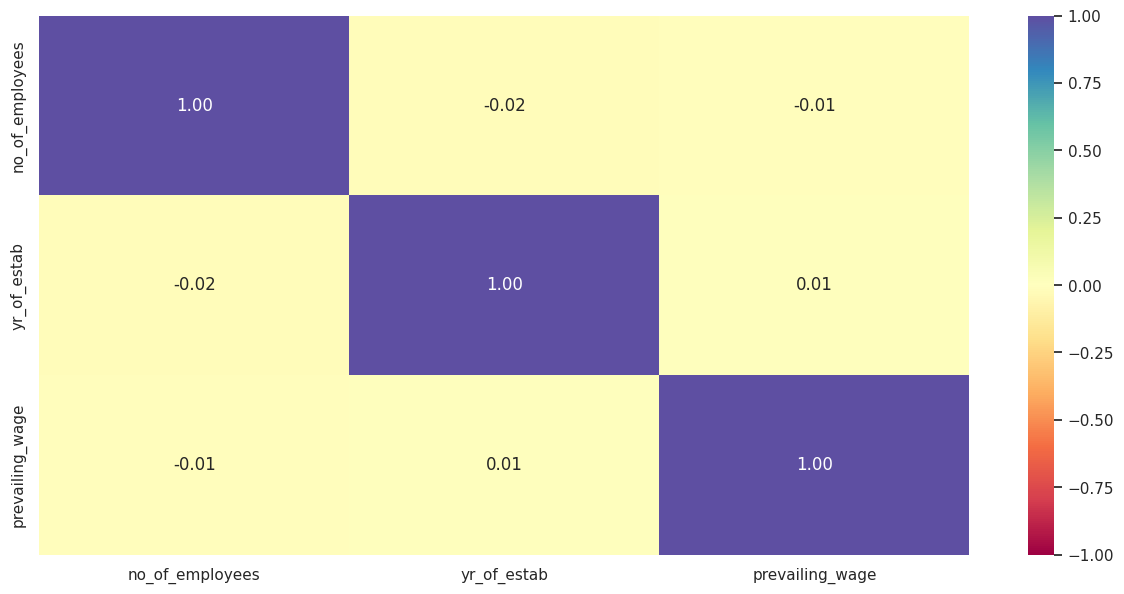

In [ ]:
plt.figure(figsize=(15, 7))
sns.heatmap(data.corr(numeric_only=True), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral")
plt.show()

The numerical variables exhibit generally weak correlations with one another, indicating limited multicollinearity concern. This suggests that each variable may provide unique information to the predictive models.

# **Data Pre-processing**

- Missing value treatment (if needed)
- Feature engineering (if needed)
- Outlier detection and treatment (if needed)
- Preparing data for modeling
- Any other preprocessing steps (if needed)

## Treat negative number of employees

In [ ]:
# Remove impossible negative employee values from full dataset
full_data = full_data[full_data['no_of_employees'] >= 0].copy()

# Then create trial sample
data = full_data.sample(frac=0.20, random_state=42)

In [ ]:
print((full_data['no_of_employees'] < 0).sum())
print((data['no_of_employees'] < 0).sum())

0
0


Since there are only 33 data that have negative no_of_employees, I delete them so they don't affect the analysis.

## Annualize wage

To compare wages across applicants, prevailing wages were converted into annual values using standard conversion factors (40 hours per week and 52 weeks per year for hourly wages). Because the dataset does not include actual weekly working hours, this standard full-time assumption was used for consistency for all hourly observations. In the real life, I would get the real quantity of working hours for part-timers to get a more accurate analysis.

In [ ]:
# Remove impossible negative employee values
full_data = full_data[full_data['no_of_employees'] >= 0].copy()

# Create annual wage in full_data
full_data['annual_wage'] = full_data['prevailing_wage']

full_data.loc[full_data['unit_of_wage'] == 'Hour', 'annual_wage'] *= 2080
full_data.loc[full_data['unit_of_wage'] == 'Week', 'annual_wage'] *= 52
full_data.loc[full_data['unit_of_wage'] == 'Month', 'annual_wage'] *= 12

# Drop original wage column
full_data.drop(columns=['prevailing_wage','unit_of_wage'], axis=1, inplace=True)

# Then create trial data
data = full_data.sample(frac=0.20, random_state=42)

In [ ]:
full_data.head()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,full_time_position,case_status,annual_wage
0,EZYV01,Asia,High School,N,N,14513,2007,West,Y,Denied,1231782.032
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,Y,Certified,83425.650
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,Y,Denied,122996.860
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,Y,Denied,83434.030
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,Y,Certified,149907.390


In [ ]:
data.head()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,full_time_position,case_status,annual_wage
14659,EZYV14660,Asia,High School,Y,N,1870,1962,South,N,Denied,6910.740
2861,EZYV2862,Asia,Master's,N,N,1873,1843,Midwest,Y,Denied,267868.560
21437,EZYV21438,Asia,Master's,N,N,2791,1981,South,Y,Denied,311105.600
10168,EZYV10169,Asia,Master's,N,N,138,1888,Northeast,Y,Denied,474784.336
21263,EZYV21264,Asia,Master's,N,N,1945,1987,West,Y,Denied,136961.100


The annual wage variable was created in the full dataset before sampling so that both the trial dataset and final full dataset would follow the same preprocessing structure. This ensures consistency when switching from trial modeling to final modeling.

## Drop case_id column since it will not add value in the analysis

In [ ]:
# Drop original wage column
full_data.drop(columns=['case_id'], axis=1, inplace=True)

# Then create trial data
data = full_data.sample(frac=0.20, random_state=42)

In [ ]:
full_data.head()

,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,full_time_position,case_status,annual_wage
0,Asia,High School,N,N,14513,2007,West,Y,Denied,1231782.032
1,Asia,Master's,Y,N,2412,2002,Northeast,Y,Certified,83425.650
2,Asia,Bachelor's,N,Y,44444,2008,West,Y,Denied,122996.860
3,Asia,Bachelor's,N,N,98,1897,West,Y,Denied,83434.030
4,Africa,Master's,Y,N,1082,2005,South,Y,Certified,149907.390


## Split the data

In [ ]:
X = data.drop('case_status', axis=1)
y = data['case_status'].map({'Certified': 1, 'Denied': 0})

# Splitting data into training, validation and test sets:
# first we split data into 2 parts, say temporary and test

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1, stratify=y
)

# then we split the temporary set into train and validation

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=1, stratify=y_temp
)
print(X_train.shape, X_val.shape, X_test.shape)

(3053, 9) (1018, 9) (1018, 9)


## Create dummy variables

In [ ]:
# Creating dummy variables for categorical variables
X_train = pd.get_dummies(data=X_train, drop_first=True)
X_val = pd.get_dummies(data=X_val, drop_first=True)
X_test = pd.get_dummies(data=X_test, drop_first=True)

## Oversample

In [ ]:
from imblearn.over_sampling import RandomOverSampler

# Create an oversampled version of the training data only
ros = RandomOverSampler(random_state=1)

X_train_over, y_train_over = ros.fit_resample(
    X_train,
    y_train
)

print("Original training data:")
print(y_train.value_counts())

print("\nOversampled training data:")
print(y_train_over.value_counts())

Original training data:
case_status
1    2015
0    1038
Name: count, dtype: int64

Oversampled training data:
case_status
1    2015
0    2015
Name: count, dtype: int64


## Undersample

In [ ]:
from imblearn.under_sampling import RandomUnderSampler

# Create an undersampled version of the training data only
rus = RandomUnderSampler(random_state=1)

X_train_under, y_train_under = rus.fit_resample(
    X_train,
    y_train
)

print("Original training data:")
print(y_train.value_counts())

print("\nUndersampled training data:")
print(y_train_under.value_counts())

Original training data:
case_status
1    2015
0    1038
Name: count, dtype: int64

Undersampled training data:
case_status
0    1038
1    1038
Name: count, dtype: int64


# **Model Building**

In the case of EasyVisa, we need to think about the business cost of mistakes before choosing the metric.

Let’s define the target:

* 1 = Certified
* 0 = Denied

The model predicts whether a visa application should be certified.

Type 1 Error (False Positive)

Model predicts Certified, but actually Denied.

Consequences:

* A potentially unqualified application gets approved.
* Employer may hire a worker who should not have received certification.
* Regulatory/compliance risk.

Type 2 Error (False Negative)

Model predicts Denied, but actually Certified.

Consequences:

* A qualified applicant is rejected.
* Company loses a potentially valuable employee.
* Opportunity cost.

⸻

Since the main business objective is to facilitate the process of visa approval, we need to reduce type 2 error.Due to the reasons above, I will use **Recall** as the primary metric.

##Initial Model Building

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

models = []

models.append(("Bagging", BaggingClassifier(random_state=1)))
models.append(("Random forest", RandomForestClassifier(random_state=1)))
models.append(("GBM", GradientBoostingClassifier(random_state=1)))
models.append(("Adaboost", AdaBoostClassifier(random_state=1)))
models.append(("Xgboost", XGBClassifier(random_state=1, eval_metric="logloss")))
models.append(("dtree", DecisionTreeClassifier(random_state=1)))

results = []
names = []

print("\nCross-Validation Performance:\n")

for name, model in models:
    scoring = "recall"

    kfold = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=1
    )

    cv_result = cross_val_score(
        estimator=model,
        X=X_train,
        y=y_train,
        scoring=scoring,
        cv=kfold
    )

    results.append(cv_result)
    names.append(name)

    print("{}: {}".format(name, cv_result.mean() * 100))


print("\nValidation Performance:\n")

validation_results = []

for name, model in models:
    model.fit(X_train, y_train)

    y_pred = model.predict(X_val)

    validation_results.append({
        "Model": name,
        "Recall": recall_score(y_val, y_pred),
        "Precision": precision_score(y_val, y_pred),
        "F1": f1_score(y_val, y_pred),
        "Accuracy": accuracy_score(y_val, y_pred)
    })

validation_results = pd.DataFrame(validation_results)

validation_results.sort_values(
    by="Recall",
    ascending=False
)


Cross-Validation Performance:

Bagging: 75.63275434243175
Random forest: 83.32506203473946
GBM: 86.55086848635236
Adaboost: 89.82630272952855
Xgboost: 82.13399503722086
dtree: 72.95285359801488

Validation Performance:



,Model,Recall,Precision,F1,Accuracy
3,Adaboost,0.869048,0.737374,0.797814,0.709234
2,GBM,0.851190,0.750656,0.797768,0.715128
1,Random forest,0.803571,0.728745,0.764331,0.672888
4,Xgboost,0.791667,0.732782,0.761087,0.671906
0,Bagging,0.751488,0.750371,0.750929,0.670923
5,dtree,0.699405,0.717557,0.708365,0.619843


AdaBoost achieved the highest cross-validation recall (89.83%) and the highest validation recall (86.90%), indicating strong ability to identify applicants who should be certified. GBM also performed strongly, with validation recall of 85.12%, while achieving the highest precision (75.07%) and accuracy (71.51%) among the models. Its F1-score (79.78%) was nearly identical to AdaBoost, suggesting a good balance between recall and precision. Random Forest achieved the third-highest validation recall (80.36%) and showed reasonably consistent performance. Therefore, AdaBoost, GBM, and Random Forest will be selected for further evaluation and tuning.

## Oversample Model Building

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

models = []

models.append(("Bagging", BaggingClassifier(random_state=1)))
models.append(("Random forest", RandomForestClassifier(random_state=1)))
models.append(("GBM", GradientBoostingClassifier(random_state=1)))
models.append(("Adaboost", AdaBoostClassifier(random_state=1)))
models.append(("Xgboost", XGBClassifier(random_state=1, eval_metric="logloss")))
models.append(("dtree", DecisionTreeClassifier(random_state=1)))

results = []
names = []

print("\nCross-Validation Performance:\n")

for name, model in models:
    scoring = "recall"

    kfold = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=1
    )

    cv_result = cross_val_score(
    estimator=model,
    X=X_train_over,
    y=y_train_over,
    scoring=scoring,
    cv=kfold
)

    results.append(cv_result)
    names.append(name)

    print("{}: {}".format(name, cv_result.mean() * 100))


print("\nValidation Performance:\n")

validation_results = []

for name, model in models:
    model.fit(X_train_over, y_train_over)

    y_pred = model.predict(X_val)

    validation_results.append({
        "Model": name,
        "Recall": recall_score(y_val, y_pred),
        "Precision": precision_score(y_val, y_pred),
        "F1": f1_score(y_val, y_pred),
        "Accuracy": accuracy_score(y_val, y_pred)
    })

validation_results = pd.DataFrame(validation_results)

validation_results.sort_values(
    by="Recall",
    ascending=False
)



Cross-Validation Performance:

Bagging: 68.8833746898263
Random forest: 76.02977667493796
GBM: 70.71960297766748
Adaboost: 72.25806451612902
Xgboost: 74.29280397022333
dtree: 71.46401985111662

Validation Performance:



,Model,Recall,Precision,F1,Accuracy
1,Random forest,0.754464,0.750000,0.752226,0.671906
4,Xgboost,0.730655,0.747336,0.738901,0.659136
5,dtree,0.694940,0.708649,0.701728,0.610020
0,Bagging,0.671131,0.772260,0.718153,0.652259
2,GBM,0.663690,0.807971,0.728758,0.673870
3,Adaboost,0.630952,0.807619,0.708438,0.657171


## Undersample Model Building


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

models = []

models.append(("Bagging", BaggingClassifier(random_state=1)))
models.append(("Random forest", RandomForestClassifier(random_state=1)))
models.append(("GBM", GradientBoostingClassifier(random_state=1)))
models.append(("Adaboost", AdaBoostClassifier(random_state=1)))
models.append(("Xgboost", XGBClassifier(random_state=1, eval_metric="logloss")))
models.append(("dtree", DecisionTreeClassifier(random_state=1)))

results = []
names = []

print("\nCross-Validation Performance:\n")

for name, model in models:
    scoring = "recall"

    kfold = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=1
    )

    cv_result = cross_val_score(
    estimator=model,
    X=X_train_under,
    y=y_train_under,
    scoring=scoring,
    cv=kfold
)

    results.append(cv_result)
    names.append(name)

    print("{}: {}".format(name, cv_result.mean() * 100))


print("\nValidation Performance:\n")

validation_results = []

for name, model in models:
    model.fit(X_train_under, y_train_under)

    y_pred = model.predict(X_val)

    validation_results.append({
        "Model": name,
        "Recall": recall_score(y_val, y_pred),
        "Precision": precision_score(y_val, y_pred),
        "F1": f1_score(y_val, y_pred),
        "Accuracy": accuracy_score(y_val, y_pred)
    })

validation_results = pd.DataFrame(validation_results)

validation_results.sort_values(
    by="Recall",
    ascending=False
)



Cross-Validation Performance:

Bagging: 60.49609810479376
Random forest: 67.6249535488666
GBM: 70.51978818283166
Adaboost: 71.38424377554811
Xgboost: 64.5405982905983
dtree: 63.00492382014122

Validation Performance:



,Model,Recall,Precision,F1,Accuracy
2,GBM,0.665179,0.812727,0.731588,0.677800
3,Adaboost,0.662202,0.813528,0.730107,0.676817
1,Random forest,0.635417,0.798131,0.707539,0.653242
4,Xgboost,0.623512,0.786116,0.695436,0.639489
5,dtree,0.580357,0.761719,0.658784,0.603143
0,Bagging,0.553571,0.798283,0.653779,0.612967


**Comparison of Sampling Strategies**

Models were evaluated using the original, oversampled, and undersampled training datasets to investigate the effect of class imbalance. Although both resampling methods created balanced training datasets, they did not improve validation recall. The models trained on the original dataset generally achieved higher recall and F1-scores than those trained on the oversampled or undersampled datasets. In particular, AdaBoost and GBM achieved validation recall scores of approximately 86.9% and 85.1% on the original data, substantially higher than their performance after resampling. T**herefore, the original training dataset will be used for further model tuning.**

# **Model Performance Improvement**

## **Note**

1. Sample parameter grids have been provided to do necessary hyperparameter tuning. These sample grids are expected to provide a balance between model performance improvement and execution time. One can extend/reduce the parameter grid based on execution time and system configuration.
  - Please note that if the parameter grid is extended to improve the model performance further, the execution time will increase
2. The models chosen in this notebook are based on test runs. One can update the best models as obtained upon code execution and tune them for best performance.

- For Gradient Boosting:

```
param_grid = {
    "init": [AdaBoostClassifier(random_state=1),DecisionTreeClassifier(random_state=1)],
    "n_estimators": np.arange(50,110,25),
    "learning_rate": [0.01,0.1,0.05],
    "subsample":[0.7,0.9],
    "max_features":[0.5,0.7,1],
}
```

- For Adaboost:

```
param_grid = {
    "n_estimators": np.arange(50,110,25),
    "learning_rate": [0.01,0.1,0.05],
    "base_estimator": [
        DecisionTreeClassifier(max_depth=2, random_state=1),
        DecisionTreeClassifier(max_depth=3, random_state=1),
    ],
}
```

- For Bagging Classifier:

```
param_grid = {
    'max_samples': [0.8,0.9,1],
    'max_features': [0.7,0.8,0.9],
    'n_estimators' : [30,50,70],
}
```
- For Random Forest:

```
param_grid = {
    "n_estimators": [50,110,25],
    "min_samples_leaf": np.arange(1, 4),
    "max_features": [np.arange(0.3, 0.6, 0.1),'sqrt'],
    "max_samples": np.arange(0.4, 0.7, 0.1)
}
```

- For Decision Trees:

```
param_grid = {
    'max_depth': np.arange(2,6),
    'min_samples_leaf': [1, 4, 7],
    'max_leaf_nodes' : [10, 15],
    'min_impurity_decrease': [0.0001,0.001]
}
```

- For XGBoost:

```
param_grid={'n_estimators':np.arange(50,110,25),
            'scale_pos_weight':[1,2,5],
            'learning_rate':[0.01,0.1,0.05],
            'gamma':[1,3],
            'subsample':[0.7,0.9]
}
```


##Hyperparameter Tuning

We will tune AdaBoost, GBM, and Random Forest using hyperparameter tuning. These three models were selected based on their strong performance on the original training data, with Recall used as the primary evaluation metric. We will compare the tuned models using validation Recall, Precision, F1-score, and Accuracy.

First let's create two functions to calculate different metrics and confusion matrix, so that we don't have to use the same code repeatedly for each model.

In [ ]:
# defining a function to compute different metrics to check performance of a classification model built using sklearn
def model_performance_classification_sklearn(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred)  # to compute Recall
    precision = precision_score(target, pred)  # to compute Precision
    f1 = f1_score(target, pred)  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {
            "Accuracy": acc,
            "Recall": recall,
            "Precision": precision,
            "F1": f1,
        },
        index=[0],
    )

    return df_perf

In [ ]:
def confusion_matrix_sklearn(model, predictors, target):
    """
    To plot the confusion_matrix with percentages

    model: classifier
    predictors: independent variables
    target: dependent variable
    """
    y_pred = model.predict(predictors)
    cm = confusion_matrix(target, y_pred)
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")

### GBM

GridSearchCV

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
import numpy as np
from sklearn.model_selection import GridSearchCV
from sklearn import metrics

# Creating pipeline with GradientBoostingClassifier
model = GradientBoostingClassifier(random_state=1)

# Parameter grid for GradientBoostingClassifier
param_grid = {
    "init": [AdaBoostClassifier(random_state=1),DecisionTreeClassifier(random_state=1)],
    "n_estimators": np.arange(50,110,25),
    "learning_rate": [0.01,0.1,0.05],
    "subsample":[0.7,0.9],
    "max_features":[0.5,0.7,1],
}

# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.recall_score)

# Calling GridSearchCV
grid_cv_gbm = GridSearchCV(estimator=model, param_grid=param_grid, scoring=scorer, cv=5, verbose=2, n_jobs=-1)

# Fitting parameters in GridSeachCV
grid_cv_gbm.fit(X_train, y_train)

print("Best Parameters:{}\nScore: {}".format(grid_cv_gbm.best_params_, grid_cv_gbm.best_score_))


Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best Parameters:{'init': AdaBoostClassifier(random_state=1), 'learning_rate': 0.01, 'max_features': 1, 'n_estimators': np.int64(100), 'subsample': 0.7}
Score: 0.939454094292804


In [ ]:
# Creating new pipeline with best parameters for GBM
# Best tuned GBM from GridSearchCV
gbm_tuned = grid_cv_gbm.best_estimator_

# Fit on the original training data
gbm_tuned.fit(X_train, y_train)

GradientBoostingClassifier(init=AdaBoostClassifier(random_state=1),
                           learning_rate=0.01, max_features=1,
                           n_estimators=np.int64(100), random_state=1,
                           subsample=0.7)

In [ ]:
# Calculating different metrics on train set
gbm_grid_train = model_performance_classification_sklearn(
    gbm_tuned, X_train, y_train
)
print("Training performance:")
gbm_grid_train

Training performance:


,Accuracy,Recall,Precision,F1
0,0.722568,0.937469,0.723755,0.816865


In [ ]:
# Calculating different metrics on validation set
gbm_grid_val = model_performance_classification_sklearn(gbm_tuned, X_val, y_val)
print("Validation performance:")
gbm_grid_val

Validation performance:


,Accuracy,Recall,Precision,F1
0,0.704322,0.910714,0.717468,0.802623


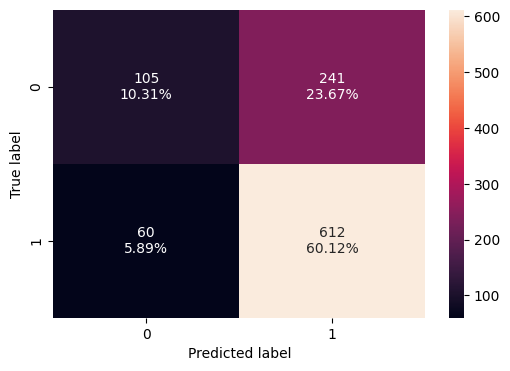

In [ ]:
# creating confusion matrix
confusion_matrix_sklearn(gbm_tuned, X_val, y_val)

The tuned GBM model shows strong performance in identifying the positive class, achieving a validation recall of 91.07% and an F1-score of 80.26%. The training and validation performances are relatively close, suggesting that the model generalizes well without substantial overfitting. However, the model produces a relatively high number of false positives (241), indicating a trade-off between high recall and precision.

RandomizedSearchCV

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
import numpy as np
from sklearn.model_selection import RandomizedSearchCV # Added import statement
from sklearn import metrics

# Creating pipeline with GradientBoostingClassifier
model = GradientBoostingClassifier(random_state=1)

# Parameter grid to pass in RandomizedSearchCV
param_grid = {
    "init": [AdaBoostClassifier(random_state=1),DecisionTreeClassifier(random_state=1)],
    "n_estimators": np.arange(50,110,25),
    "learning_rate": [0.01,0.1,0.05],
    "subsample":[0.7,0.9],
    "max_features":[0.5,0.7,1],
}

# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.recall_score)

# Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_grid,
    n_iter=20,
    scoring=scorer,
    cv=5,
    random_state=1,
    verbose=2,
    n_jobs=-1
)

# Fitting parameters in RandomizedSearchCV
randomized_cv.fit(X_train, y_train)

print(
    "Best parameters are {} with CV score={}:".format(
        randomized_cv.best_params_, randomized_cv.best_score_
    )
)


Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters are {'subsample': 0.7, 'n_estimators': np.int64(50), 'max_features': 1, 'learning_rate': 0.05, 'init': AdaBoostClassifier(random_state=1)} with CV score=0.9374689826302729:


In [ ]:
# Best tuned GBM from RandomizedSearchCV
gbm_tuned_randomized = randomized_cv.best_estimator_

# Fit the model on the original training data
gbm_tuned_randomized.fit(X_train, y_train)

GradientBoostingClassifier(init=AdaBoostClassifier(random_state=1),
                           learning_rate=0.05, max_features=1,
                           n_estimators=np.int64(50), random_state=1,
                           subsample=0.7)

In [ ]:
# Calculating different metrics on train set
gbm_random_train = model_performance_classification_sklearn(
    gbm_tuned_randomized, X_train, y_train
)
print("Training performance:")
gbm_random_train

Training performance:


,Accuracy,Recall,Precision,F1
0,0.727154,0.940943,0.726437,0.819892


In [ ]:
# Calculating different metrics on validation set
gbm_random_val = model_performance_classification_sklearn(gbm_tuned_randomized, X_val, y_val)
print("Validation performance:")
gbm_random_val

Validation performance:


,Accuracy,Recall,Precision,F1
0,0.700393,0.912202,0.71362,0.800784


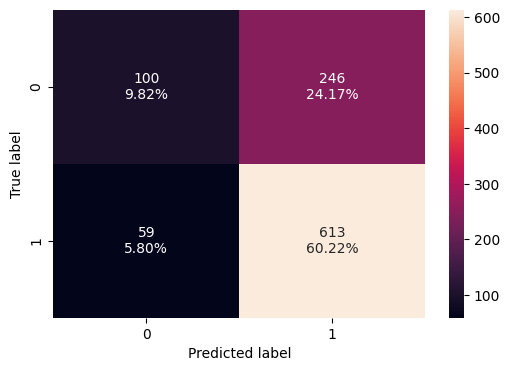

In [ ]:
# creating confusion matrix
confusion_matrix_sklearn(gbm_tuned_randomized, X_val, y_val)

The GBM tuned with RandomizedSearchCV achieved a validation recall of 91.22%, slightly higher than the 91.07% obtained using GridSearchCV. The two models produced very similar overall performance, although GridSearchCV achieved slightly higher precision, F1-score, and accuracy. RandomizedSearchCV required substantially fewer model fits while achieving comparable results, making it a more computationally efficient tuning approach. Since recall is the primary metric for this analysis, the RandomizedSearchCV GBM is currently the preferred GBM model.

###Adaboost

GridSearchCV

In [ ]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn import metrics
import numpy as np

# Create AdaBoost model
ada_model = AdaBoostClassifier(random_state=1)

# Professor's parameter grid
ada_param_grid = {
    "n_estimators": np.arange(50, 110, 25),
    "learning_rate": [0.01, 0.1, 0.05],
    "estimator": [
        DecisionTreeClassifier(max_depth=2, random_state=1),
        DecisionTreeClassifier(max_depth=3, random_state=1)
    ]
}

# Recall is our primary metric
ada_scorer = metrics.make_scorer(metrics.recall_score)

# GridSearchCV
grid_cv_ada = GridSearchCV(
    estimator=ada_model,
    param_grid=ada_param_grid,
    scoring=ada_scorer,
    cv=5,
    verbose=2,
    n_jobs=-1
)

# Use ORIGINAL training data
grid_cv_ada.fit(X_train, y_train)

print(
    "Best Parameters:{}\nCV Recall: {}".format(
        grid_cv_ada.best_params_,
        grid_cv_ada.best_score_
    )
)

Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best Parameters:{'estimator': DecisionTreeClassifier(max_depth=3, random_state=1), 'learning_rate': 0.01, 'n_estimators': np.int64(50)}
CV Recall: 0.9349875930521092


In [ ]:
# Creating new pipeline with best parameters for Adaboost
ada_tuned = grid_cv_ada.best_estimator_

ada_tuned.fit(X_train, y_train)

AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=3,
                                                    random_state=1),
                   learning_rate=0.01, n_estimators=np.int64(50),
                   random_state=1)

In [ ]:
# Calculating different metrics on train set
ada_grid_train = model_performance_classification_sklearn(
    ada_tuned,
    X_train,
    y_train
)

print("Training performance:")
ada_grid_train

Training performance:


,Accuracy,Recall,Precision,F1
0,0.712742,0.931017,0.717674,0.810542


In [ ]:
# Calculating different metrics on validation set
ada_grid_val = model_performance_classification_sklearn(
    ada_tuned,
    X_val,
    y_val
)

print("Validation performance:")
ada_grid_val

Validation performance:


,Accuracy,Recall,Precision,F1
0,0.707269,0.912202,0.719484,0.804462


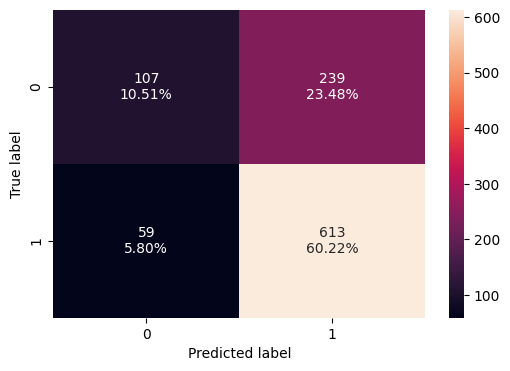

In [ ]:
# creating confusion matrix
confusion_matrix_sklearn(
    ada_tuned,
    X_val,
    y_val
)

The tuned AdaBoost model achieved a validation recall of 91.22%, indicating that it successfully identified most of the positive cases. Training recall (93.10%) and validation recall (91.22%) are relatively close, suggesting that the model generalizes reasonably well without substantial overfitting. The model also achieved a validation precision of 71.95% and an F1-score of 80.45%. Compared with the tuned GBM models, AdaBoost provides competitive recall with slightly better overall validation performance.

RandomizedSearchCV

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

# AdaBoost model
ada_model_random = AdaBoostClassifier(random_state=1)

# Professor's AdaBoost parameter grid
ada_param_grid = {
    "n_estimators": np.arange(50, 110, 25),
    "learning_rate": [0.01, 0.1, 0.05],
    "estimator": [
        DecisionTreeClassifier(max_depth=2, random_state=1),
        DecisionTreeClassifier(max_depth=3, random_state=1)
    ]
}

# Recall is the primary metric
ada_scorer = metrics.make_scorer(metrics.recall_score)

# RandomizedSearchCV
randomized_cv_ada = RandomizedSearchCV(
    estimator=ada_model_random,
    param_distributions=ada_param_grid,
    n_iter=10,
    scoring=ada_scorer,
    cv=5,
    random_state=1,
    verbose=2,
    n_jobs=-1
)

# Fit on original training data
randomized_cv_ada.fit(X_train, y_train)

print(
    "Best parameters are {} with CV Recall={}".format(
        randomized_cv_ada.best_params_,
        randomized_cv_ada.best_score_
    )
)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best parameters are {'n_estimators': np.int64(75), 'learning_rate': 0.01, 'estimator': DecisionTreeClassifier(max_depth=3, random_state=1)} with CV Recall=0.9330024813895783


In [ ]:
# Creating new pipeline with best parameters from RandomizedSearchCV
ada_random_tuned = randomized_cv_ada.best_estimator_

ada_random_tuned.fit(X_train, y_train)

AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=3,
                                                    random_state=1),
                   learning_rate=0.01, n_estimators=np.int64(75),
                   random_state=1)

In [ ]:
# Calculating different metrics on train set
ada_random_train = model_performance_classification_sklearn(
    ada_random_tuned,
    X_train,
    y_train
)

print("Training performance:")
ada_random_train

Training performance:


,Accuracy,Recall,Precision,F1
0,0.713397,0.932506,0.717723,0.811137


In [ ]:
# Calculating different metrics on validation set
ada_random_val = model_performance_classification_sklearn(
    ada_random_tuned,
    X_val,
    y_val
)

print("Validation performance:")
ada_random_val

Validation performance:


,Accuracy,Recall,Precision,F1
0,0.704322,0.912202,0.716959,0.802881


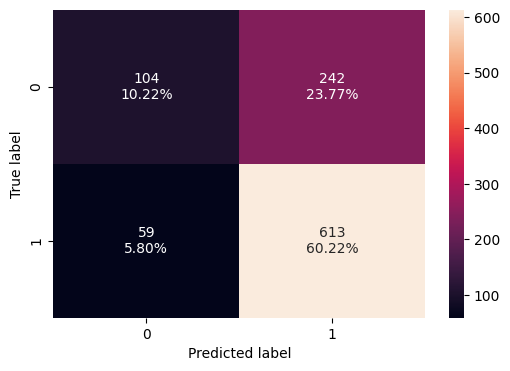

In [ ]:
# creating confusion matrix
confusion_matrix_sklearn(
    ada_random_tuned,
    X_val,
    y_val
)

AdaBoost tuned with RandomizedSearchCV achieved a validation recall of 91.22%, matching the GridSearchCV model. However, the GridSearchCV model achieved slightly higher precision, F1-score, and accuracy. Therefore, AdaBoost GridSearchCV is preferred, although RandomizedSearchCV achieved very similar performance with fewer model fits.

###Random Forest

GridSearch CV


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn import metrics
import numpy as np

# Create Random Forest model
rf_model = RandomForestClassifier(random_state=1)

# Professor's parameter grid
rf_param_grid = {
    "n_estimators": np.arange(50, 110, 25),
    "min_samples_leaf": np.arange(1, 4),
    "max_features": [0.3, 0.4, 0.5, "sqrt"],
    "max_samples": np.arange(0.4, 0.7, 0.1)
}

# Recall is the primary metric
rf_scorer = metrics.make_scorer(metrics.recall_score)

# GridSearchCV
grid_cv_rf = GridSearchCV(
    estimator=rf_model,
    param_grid=rf_param_grid,
    scoring=rf_scorer,
    cv=5,
    verbose=2,
    n_jobs=-1
)

# Fit on original training data
grid_cv_rf.fit(X_train, y_train)

print(
    "Best Parameters:{}\nCV Recall: {}".format(
        grid_cv_rf.best_params_,
        grid_cv_rf.best_score_
    )
)

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best Parameters:{'max_features': 'sqrt', 'max_samples': np.float64(0.4), 'min_samples_leaf': np.int64(2), 'n_estimators': np.int64(75)}
CV Recall: 0.8799007444168735


In [ ]:
rf_tuned = grid_cv_rf.best_estimator_

rf_tuned.fit(X_train, y_train)

RandomForestClassifier(max_samples=np.float64(0.4),
                       min_samples_leaf=np.int64(2), n_estimators=np.int64(75),
                       random_state=1)

In [ ]:
rf_grid_train = model_performance_classification_sklearn(
    rf_tuned,
    X_train,
    y_train
)

print("Training performance:")
rf_grid_train

Training performance:


,Accuracy,Recall,Precision,F1
0,0.842778,0.950868,0.834131,0.888683


In [ ]:
rf_grid_val = model_performance_classification_sklearn(
    rf_tuned,
    X_val,
    y_val
)

print("Validation performance:")
rf_grid_val

Validation performance:


,Accuracy,Recall,Precision,F1
0,0.710216,0.863095,0.740741,0.797251


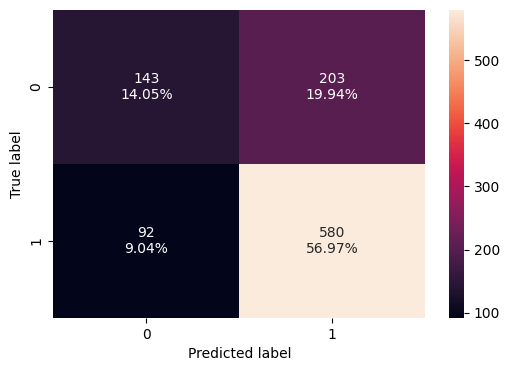

In [ ]:
confusion_matrix_sklearn(
    rf_tuned,
    X_val,
    y_val
)

The tuned Random Forest achieved a validation recall of 86.31%, precision of 74.07%, and F1-score of 79.73%. Although its precision is relatively high, the substantial difference between training and validation performance indicates some overfitting. Since recall is the primary evaluation metric, the tuned Random Forest performs worse than the tuned AdaBoost and GBM models.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn import metrics
import numpy as np

# Create Random Forest model
rf_model_random = RandomForestClassifier(random_state=1)

# Same parameter grid used for GridSearchCV
rf_param_grid = {
    "n_estimators": np.arange(50, 110, 25),
    "min_samples_leaf": np.arange(1, 4),
    "max_features": [0.3, 0.4, 0.5, "sqrt"],
    "max_samples": np.arange(0.4, 0.7, 0.1)
}

# Recall is the primary metric
rf_scorer = metrics.make_scorer(metrics.recall_score)

# RandomizedSearchCV
randomized_cv_rf = RandomizedSearchCV(
    estimator=rf_model_random,
    param_distributions=rf_param_grid,
    n_iter=20,
    scoring=rf_scorer,
    cv=5,
    random_state=1,
    verbose=2,
    n_jobs=-1
)

# Fit on original training data
randomized_cv_rf.fit(X_train, y_train)

print(
    "Best parameters are {} with CV Recall={}".format(
        randomized_cv_rf.best_params_,
        randomized_cv_rf.best_score_
    )
)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters are {'n_estimators': np.int64(100), 'min_samples_leaf': np.int64(3), 'max_samples': np.float64(0.4), 'max_features': 'sqrt'} with CV Recall=0.8799007444168734


In [ ]:
rf_random_tuned = randomized_cv_rf.best_estimator_

rf_random_tuned.fit(X_train, y_train)

RandomForestClassifier(max_samples=np.float64(0.4),
                       min_samples_leaf=np.int64(3), n_estimators=np.int64(100),
                       random_state=1)

In [ ]:
rf_random_train = model_performance_classification_sklearn(
    rf_random_tuned,
    X_train,
    y_train
)

print("Training performance:")
rf_random_train

Training performance:


,Accuracy,Recall,Precision,F1
0,0.80511,0.934491,0.802643,0.863563


In [ ]:
rf_random_val = model_performance_classification_sklearn(
    rf_random_tuned,
    X_val,
    y_val
)

print("Validation performance:")
rf_random_val

Validation performance:


,Accuracy,Recall,Precision,F1
0,0.714145,0.869048,0.742058,0.800548


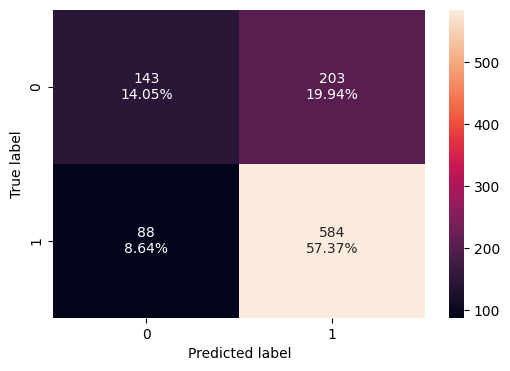

In [ ]:
confusion_matrix_sklearn(
    rf_random_tuned,
    X_val,
    y_val
)

# **Model Comparison and Final Model Selection**

In [ ]:
# Training performance comparison

models_train_comp_df = pd.concat(
    [
        gbm_grid_train.T,
        gbm_random_train.T,
        ada_grid_train.T,
        ada_random_train.T,
        rf_grid_train.T,
        rf_random_train.T
    ],
    axis=1,
)

models_train_comp_df.columns = [
    "GBM - GridSearchCV",
    "GBM - RandomizedSearchCV",
    "AdaBoost - GridSearchCV",
    "AdaBoost - RandomizedSearchCV",
    "Random Forest - GridSearchCV",
    "Random Forest - RandomizedSearchCV"
]

print("Training performance comparison:")
models_train_comp_df

Training performance comparison:


,GBM - GridSearchCV,GBM - RandomizedSearchCV,AdaBoost - GridSearchCV,AdaBoost - RandomizedSearchCV,Random Forest - GridSearchCV,Random Forest - RandomizedSearchCV
Accuracy,0.722568,0.727154,0.712742,0.713397,0.842778,0.805110
Recall,0.937469,0.940943,0.931017,0.932506,0.950868,0.934491
Precision,0.723755,0.726437,0.717674,0.717723,0.834131,0.802643
F1,0.816865,0.819892,0.810542,0.811137,0.888683,0.863563


In [ ]:
# Validation performance comparison

models_val_comp_df = pd.concat(
    [
        gbm_grid_val.T,
        gbm_random_val.T,
        ada_grid_val.T,
        ada_random_val.T,
        rf_grid_val.T,
        rf_random_val.T
    ],
    axis=1,
)

models_val_comp_df.columns = [
    "GBM - GridSearchCV",
    "GBM - RandomizedSearchCV",
    "AdaBoost - GridSearchCV",
    "AdaBoost - RandomizedSearchCV",
    "Random Forest - GridSearchCV",
    "Random Forest - RandomizedSearchCV"
]

print("Validation performance comparison:")
models_val_comp_df

Validation performance comparison:


,GBM - GridSearchCV,GBM - RandomizedSearchCV,AdaBoost - GridSearchCV,AdaBoost - RandomizedSearchCV,Random Forest - GridSearchCV,Random Forest - RandomizedSearchCV
Accuracy,0.704322,0.700393,0.707269,0.704322,0.710216,0.714145
Recall,0.910714,0.912202,0.912202,0.912202,0.863095,0.869048
Precision,0.717468,0.713620,0.719484,0.716959,0.740741,0.742058
F1,0.802623,0.800784,0.804462,0.802881,0.797251,0.800548


The AdaBoost model tuned with GridSearchCV was selected as the final model. Recall was prioritized because the business objective is to correctly identify applicants who are likely to receive visa certification. AdaBoost GridSearchCV achieved one of the highest validation Recall scores (91.22%). Among the models with the same Recall, it also achieved the highest Precision, F1-score, and Accuracy. In addition, its training and validation performance were reasonably close, indicating good generalization. Therefore, AdaBoost GridSearchCV was selected for final evaluation on the test set.

In [ ]:
# Final model performance on test set

ada_test = model_performance_classification_sklearn(
    ada_tuned,
    X_test,
    y_test
)

print("Test performance of final AdaBoost model:")
ada_test

Test performance of final AdaBoost model:


,Accuracy,Recall,Precision,F1
0,0.714145,0.94494,0.714286,0.813581


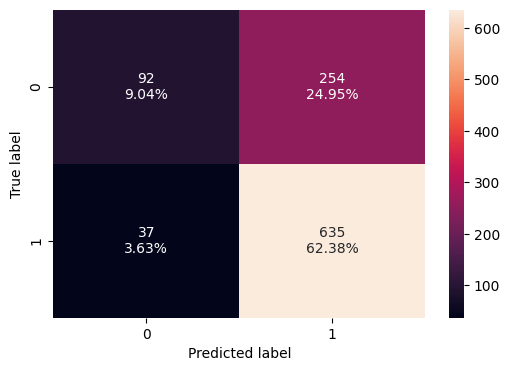

In [ ]:
confusion_matrix_sklearn(
    ada_tuned,
    X_test,
    y_test
)

The test recall of 94.49% is consistent with the strong validation performance, providing evidence that the model generalizes well to unseen data.

##Feature Importance

In [ ]:
# Feature importance of the final AdaBoost model

importances = ada_tuned.feature_importances_

feature_names = X_train.columns

feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
)

feature_importance_df

,Feature,Importance
9,education_of_employee_High School,0.451428
11,has_job_experience_Y,0.269254
4,continent_Europe,0.115091
10,education_of_employee_Master's,0.094534
2,annual_wage,0.038388
16,region_of_employment_West,0.011431
13,region_of_employment_Midwest,0.008712
5,continent_North America,0.004526
3,continent_Asia,0.003520
0,no_of_employees,0.003117


* Education level is the most influential factor in the final AdaBoost model. In particular, education_of_employee_High School has the highest feature importance at approximately 45.1%, followed by education_of_employee_Master's at about 9.5%. This suggests that the applicant’s education level plays an important role in predicting visa certification outcomes.
* Previous job experience is also highly important. has_job_experience_Y contributes approximately 26.9% of the model’s total feature importance, making it the second most influential predictor. This indicates that applicants with prior job experience provide meaningful information for predicting visa approval outcomes.
* Geographic and wage-related factors have moderate importance. continent_Europe contributes approximately 11.5%, while annual_wage contributes about 3.8%. Other geographic variables, such as region of employment and continent, have relatively small contributions.
* Several variables, including yr_of_estab, education_of_employee_Doctorate, requires_job_training_Y, some employment regions, and full_time_position_Y, have little or no importance in the final model. This means the AdaBoost model relied much less on these variables when making its predictions.

Overall, the model indicates that education level and previous job experience are the dominant predictive factors, while wage and geographic characteristics provide additional but smaller predictive value.

# **Actionable Insights and Recommendations**

1. Focus on Applicant Education and Work Experience

The final AdaBoost model identified education level and previous job experience as the most important predictive factors for visa certification outcomes. These characteristics therefore provide useful information when assessing the likelihood of certification.

Recommendation: EasyVisa can use education and work-experience information as important inputs in its screening and advisory process. Applications involving these factors should also be carefully reviewed to ensure that qualifications and prior experience are clearly and accurately documented.

2. Pay Attention to Wage Information

Although less influential than education and work experience, annual wage also contributes to the model’s predictions. This suggests that compensation information provides additional value when assessing visa certification outcomes.

Recommendation: Employers and EasyVisa consultants should verify that wage information is complete, accurate, and appropriate for the proposed position before submitting an application. Applications with unusual wage characteristics may benefit from additional review.

3. Use the Model as an Early-Screening Tool

The final AdaBoost model achieved a 94.49% recall on the test set, meaning that it successfully identified most applicants belonging to the positive certification class. This makes the model particularly useful as an initial screening tool when the goal is to minimize missed potential certifications.

Recommendation: EasyVisa can use the model to identify applications with a high predicted likelihood of certification and support consultants in prioritizing case review and resource allocation. However, model predictions should support rather than replace professional review.

4. Review Lower-Confidence Applications More Carefully

The model achieved 71.43% precision, meaning that some applicants predicted as positive were not actually certified. Therefore, a positive model prediction should not automatically be treated as a successful outcome.

Recommendation: Cases predicted as positive should still undergo document verification and professional review. EasyVisa could also use prediction probabilities to identify borderline cases that require additional attention before submission.

5. Continue Monitoring and Updating the Model

Visa certification patterns may change over time due to labor-market conditions, applicant characteristics, or immigration policies.

Recommendation: EasyVisa should periodically monitor model performance and retrain the model when new application data becomes available. Particular attention should be given to recall, precision, and changes in the importance of key predictors.
